# Analyse financial forecasting results

This notebook analyses the frozen test-set predictions without retraining or rerunning inference.  All calculations and plotting logic live in `src/evaluation/result_analysis.py`; notebook cells contain only paths, explicit function inputs, and displays.

The analysis focuses on why persistence is strong, how performance varies across stocks, how results differ by test-period realised volatility, how metrics vary by the **actual target bar-close time**, and whether GraphTCN's daily advantage changes with market volatility.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import torch
from IPython.display import display

# Resolve the repository root before importing project modules.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_candle_data import (
    clean_candle_splits,
    load_candle_splits,
)
from src.evaluation.result_analysis import (
    FinancialResultAnalysis,
    PredictionSource,
    make_time_of_day_metric_table,
    make_top_bottom_stock_table,
    plot_adf_pvalues_by_stock,
    plot_daily_error_difference,
    plot_daily_metric_vs_volatility,
    plot_metric_by_stock_volatility,
    plot_metric_vs_adf,
    plot_persistence_headroom,
    plot_split_volatility_distribution,
    plot_stock_metric_by_horizon,
    plot_stock_metric_ecdf,
    plot_time_of_day_metric,
    summarise_daily_metric_vs_volatility,
    plot_price_forecasts_across_days,
)


## Load and align the saved predictions

Every model must contain exactly the same stocks, horizons, forecast windows, targets, session indices, origin indices, and target indices.  The loader fails rather than silently comparing different observations.

The paths below identify data and saved artefacts only.  Model, metric, horizon, ordering, and benchmark choices remain explicit inside each later function call.

In [4]:
# Input paths:
# - DATA_DIR contains train.pt, val.pt, and test.pt.
# - BASELINE_CACHE_ROOT contains each baseline prediction_result.pt.
# - FINAL_MODEL_RUN_DIR is the frozen GraphTCN run directory.
# - COMPANY_PROFILES_PATH provides the sector label for every project ticker.

DATA_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "Shared drives/Vishal/data/cached_datasets/"
    "exp-1m-95s-24y/session"
)

BASELINE_CACHE_ROOT = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation"
)

FINAL_MODEL_RUN_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/models_to_use/final_model"
)

FINAL_MODEL_TOKENS_RUN_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/models_to_use/final_model_tokens_post"
)

KRONOS_PREDICTION_PATH = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/kronos/"
    "kronos_small_test_fp16_bs16_progress.pt"
)

COMPANY_PROFILES_PATH = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/company_profiles.csv"
)

ANALYSIS_OUTPUT_DIR = Path(
    "/Users/vishalruparelia/Library/CloudStorage/"
    "GoogleDrive-vishal@autonomous-fox.ai/"
    "My Drive/dissertation/analysis/results"
)

train_raw, val_raw, test_raw = load_candle_splits(DATA_DIR)
train, val, test = clean_candle_splits(train_raw, val_raw, test_raw)

analysis = FinancialResultAnalysis.from_sources(
    model_sources={
        "Persistence": PredictionSource(
            BASELINE_CACHE_ROOT / "persistence" / "prediction_result.pt"
        ),
        "ARIMA": PredictionSource(
            BASELINE_CACHE_ROOT / "arima" / "prediction_result.pt"
        ),
        "VAR": PredictionSource(
            BASELINE_CACHE_ROOT / "var" / "prediction_result.pt"
        ),
        "GARCH": PredictionSource(
            BASELINE_CACHE_ROOT / "garch" / "prediction_result.pt"
        ),
        "ModernTCN": PredictionSource(
            BASELINE_CACHE_ROOT / "modern_tcn" / "prediction_result.pt"
        ),
        "Kronos": PredictionSource(
            KRONOS_PREDICTION_PATH,
            nested_key="prediction_result",
        ),
        "GraphTCN": PredictionSource(
            FINAL_MODEL_RUN_DIR,
            kind="evaluation_run",
            split="test",
            policy="best",
        ),
        "Token GraphTCN": PredictionSource(
            FINAL_MODEL_TOKENS_RUN_DIR,
            kind="evaluation_run",
            split="test",
            policy="best",
        ),

    },
    train_split=train,
    val_split=val,
    test_split=test,
    company_profiles_path=COMPANY_PROFILES_PATH,
    reference_model="Persistence",
)

display(analysis.alignment_manifest())


,model,display_name,windows,horizons,assets,channels,first_session,last_session,nonpositive_predictions
0,Persistence,Persistence,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0
1,ARIMA,ARIMA,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0
2,VAR,VAR,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0
3,GARCH,GARCH,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0
4,ModernTCN,ModernTCN,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0
5,Kronos,Kronos,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0
6,GraphTCN,GraphTCN,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0
7,Token GraphTCN,Token GraphTCN,1178,"(1, 5, 15, 30, 60)",93,"(close,)",2024-10-01,2024-12-31,0


## Metric registry

Stock-level plots accept metrics that are meaningful for one stock through time.  IC and Rank IC remain cross-sectional and therefore appear only in grouped analyses such as the target-time breakdown.

In [21]:
display(analysis.available_stock_metrics())
print("Group-level metrics:")
print(analysis.available_group_metrics())


,metric,display_name,direction,reference_value,description
0,cumulative_log_change_mae,Cumulative-log-change MAE,lower,NaN,Mean absolute error between predicted and real...
1,cumulative_log_change_median_absolute_error,Cumulative-log-change median absolute error,lower,NaN,Median absolute cumulative-log-change error.
2,cumulative_log_change_p95_absolute_error,Cumulative-log-change P95 absolute error,lower,NaN,95th percentile cumulative-log-change absolute...
3,mase,MASE,lower,1.0,Raw-space absolute error divided by the traini...
4,relative_mae_vs_persistence,Relative MAE vs persistence,lower,1.0,Raw-price MAE divided by same-horizon persiste...
5,mae_difference_vs_persistence,CLG-MAE minus persistence,lower,0.0,Cumulative-log-change MAE minus persistence CL...
6,persistence_win_rate,Persistence win rate,higher,0.5,Fraction of raw-price forecast elements with s...
7,cumulative_log_change_directional_accuracy,Directional accuracy,higher,0.5,Fraction of cumulative-log-change signs predic...
8,cumulative_log_change_pearson_correlation,Cumulative-log-change Pearson,higher,0.0,Temporal Pearson correlation between predicted...
9,raw_price_temporal_pearson_correlation,Price Pearson,higher,0.0,Temporal Pearson correlation between predicted...


Group-level metrics:
('cumulative_log_change_mae', 'cumulative_log_change_median_absolute_error', 'cumulative_log_change_p95_absolute_error', 'cumulative_log_change_pearson_correlation', 'raw_price_temporal_pearson_correlation', 'cumulative_log_change_directional_accuracy', 'cumulative_log_change_movement_magnitude_ratio', 'cumulative_log_change_temporal_absolute_correlation', 'mase', 'relative_mae_vs_persistence', 'persistence_win_rate', 'cumulative_log_change_cross_sectional_pearson_ic', 'cumulative_log_change_cross_sectional_spearman_rank_ic', 'forecast_series_log_return_temporal_pearson_correlation', 'mae_difference_vs_persistence')


## 1. Why is persistence strong?

For each stock, the Augmented Dickey–Fuller diagnostic is applied to the test-period sequence of daily log closing prices. In the simplified ADF regression,

$$
\Delta p_d = \alpha + \gamma p_{d-1} + \sum_{j=1}^{k}\phi_j\Delta p_{d-j}+\varepsilon_d.
$$

The null hypothesis is

$$
H_0:\gamma=0,
$$

which corresponds to a unit root. The stock-level chart places the ADF p-value on the y-axis and the selected rejection threshold on a horizontal line. A p-value below the line rejects the unit-root null at that level; a value above the line means the test fails to reject it. Failure to reject does **not** prove a random walk or prove that returns are unpredictable. The test period is short, so this remains a descriptive prior.

When `order_by="volatility"`, stocks are ordered from highest to lowest median test-period realised volatility and divided into the requested number of equal-frequency buckets. When `order_by="sector"`, sectors are grouped alphabetically and stocks are ordered from highest to lowest volatility within each sector.


,diagnostic,value
0,Stocks with valid ADF test,93.000000
1,Fail to reject unit root at 5%,90.000000
2,Fraction failing to reject unit root at 5%,0.967742
3,Median ADF p-value,0.595680
4,Median test-period stock realised volatility,0.010368


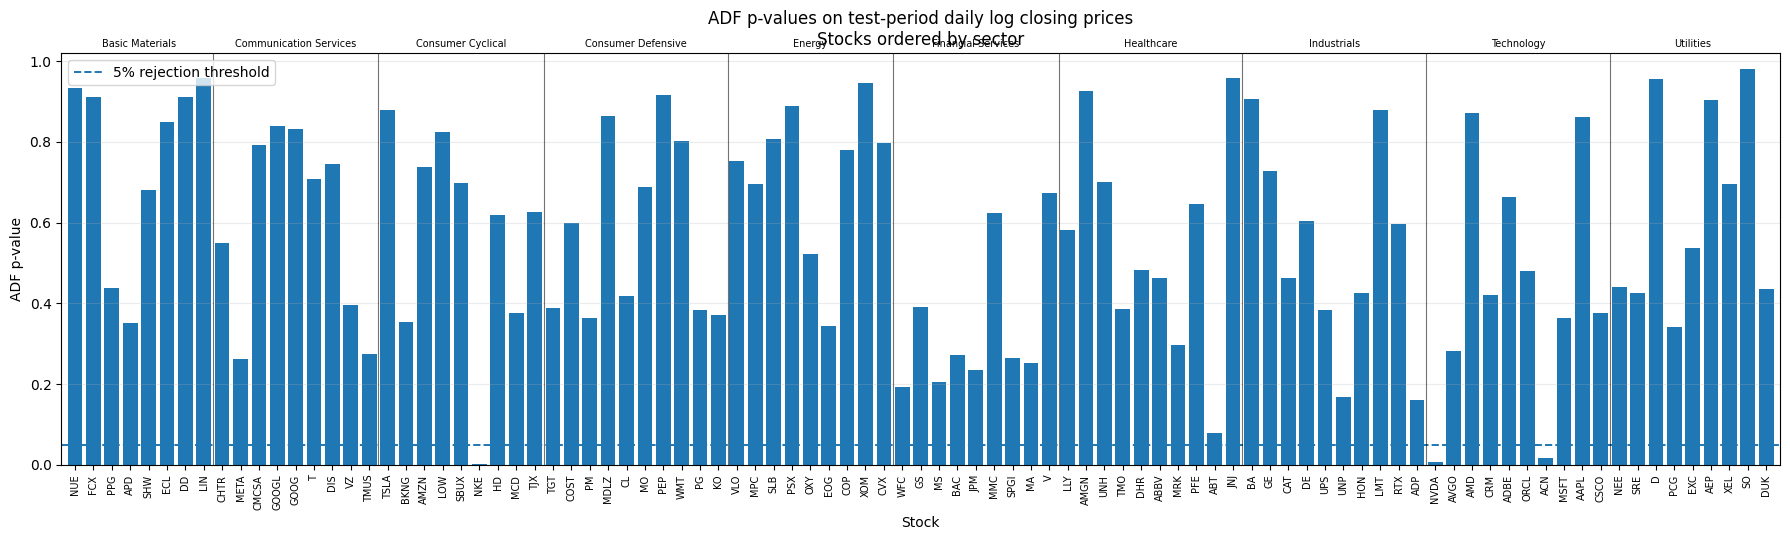

In [19]:
# Inputs:
# - significance_level sets the horizontal ADF rejection threshold.
# - order_by is either "volatility" or "sector".
# - num_volatility_buckets can be any integer from 1 to the number of stocks.

display(analysis.persistence_strength_summary())
adf_table, adf_figure = plot_adf_pvalues_by_stock(
    analysis,
    significance_level=0.05,
    order_by="sector",
    num_volatility_buckets=5,
    figsize=(18, 5.5),
)


### Was the test split unusually quiet?

For stock $n$ on session $d$, daily realised volatility is

$$
RV_{d,n}=\sqrt{\sum_{\tau\in d}\left(\Delta\log P_{\tau,n}\right)^2}.
$$

The daily market measure is the cross-stock median.  Comparing its distribution across train, validation, and test separates the claim that the test period was quiet from the separate claim that returns were unpredictable.

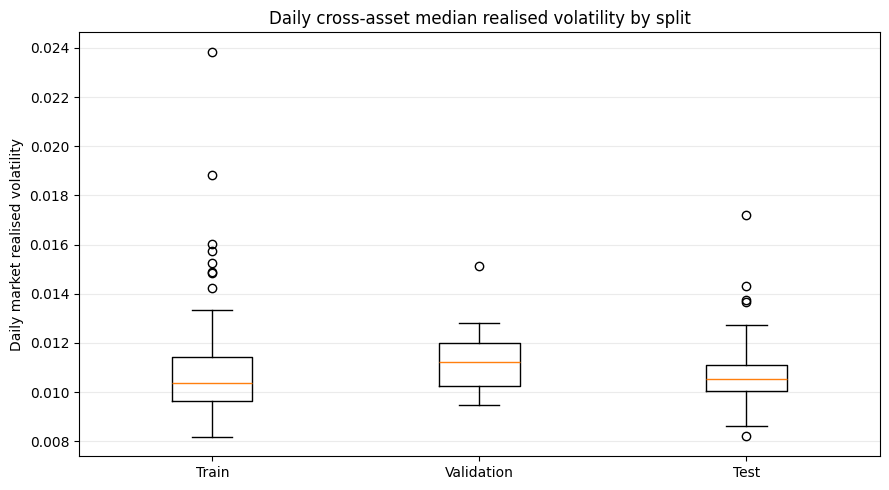

In [20]:
# Input:
# - figsize controls only the display size.

split_volatility_table, split_volatility_figure = (
    plot_split_volatility_distribution(
        analysis,
        figsize=(9, 5),
    )
)


### Does random-walk-like behaviour coincide with weaker model performance?

This plot relates each stock's ADF p-value to one explicitly selected model metric.  For relative MAE,

$$
\operatorname{RelMAE}_{h,n}
=
\frac{\operatorname{MAE}_{h,n}^{\mathrm{model}}}
{\operatorname{MAE}_{h,n}^{\mathrm{persistence}}}.
$$

Values below one favour the model.

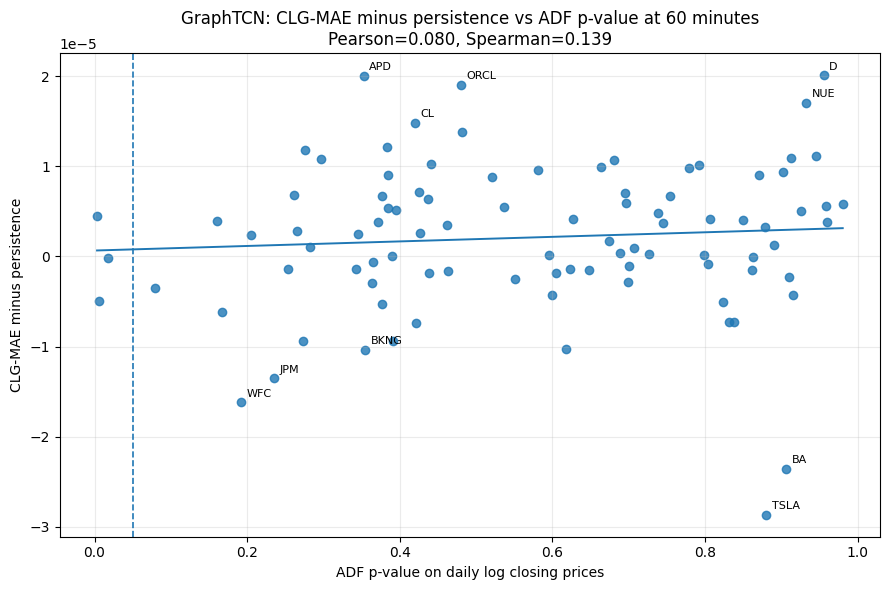

In [22]:
# Inputs:
# - model_name selects one saved model.
# - metric_name must be present in analysis.available_stock_metrics().
# - horizon is one of 1, 5, 15, 30, or 60 minutes.

adf_metric_table, adf_metric_figure = plot_metric_vs_adf(
    analysis,
    model_name="GraphTCN",
    metric_name="mae_difference_vs_persistence",
    horizon=60,
    significance_level=0.05,
    annotate_extremes=5,
)


### Persistence headroom

Persistence cumulative-log-change MAE is also the mean absolute realised movement from the forecast origin:

$$
\operatorname{MAE}^{\mathrm{pers}}_{h,n}
=
\frac{1}{T}\sum_t
\left|\log P_{t+h,n}-\log P_{t,n}\right|.
$$

Small values mean that the stock offered little absolute-error headroom over persistence.

In [ ]:
# Inputs:
# - model_name and metric_name determine the y-axis.
# - horizon determines persistence's realised-movement/headroom measure.

headroom_table, headroom_figure = plot_persistence_headroom(
    analysis,
    model_name="GraphTCN",
    metric_name="relative_mae_vs_persistence",
    horizon=60,
    annotate_extremes=5,
)


## 2. Performance by individual stock

One function call produces one independent bar chart for each selected forecast horizon. Every chart has its own **adaptive y-axis**, calculated from the finite stock-level values for that horizon. This prevents values clustered around a local benchmark—for example relative MAE near one or win rate near 0.5—from being flattened by a zero-based axis.

A nearby metric reference is included in the displayed range and drawn as a horizontal line. A distant reference, such as zero when every price correlation is close to one, is not allowed to destroy the useful scale. When zero is excluded, the plot is explicitly labelled as using an adaptive y-axis. Set `y_axis_mode="zero"` in the individual function call to recover a conventional zero-based chart.

Within every visible volatility bucket, a **red dashed horizontal segment** shows the arithmetic mean of the plotted stock-level metric for that bucket and horizon. The returned table stores the same value in `display_group_mean` for every stock in the group.

For stock $n$, test-period characteristic volatility is

$$
\widetilde{RV}_{n}=\operatorname{median}_{d}\left[\sqrt{\sum_{\tau\in d}\left(\Delta\log P_{\tau,n}\right)^2}\right].
$$

With `order_by="volatility"`, stocks are ordered from highest to lowest $\widetilde{RV}_{n}$ and separators mark the requested number of equal-frequency volatility buckets.

### Sector-grouped ordering

The same five separate bar charts can be grouped alphabetically by sector. Stocks are ordered from highest to lowest realised volatility inside each sector, and sector boundaries are shown above the x-axis. A **red dashed horizontal segment** shows the arithmetic mean of the selected metric within each sector and horizon. The `num_volatility_buckets` input is still recorded in the returned stock metadata, but sector boundaries determine the visible grouping in this ordering mode.


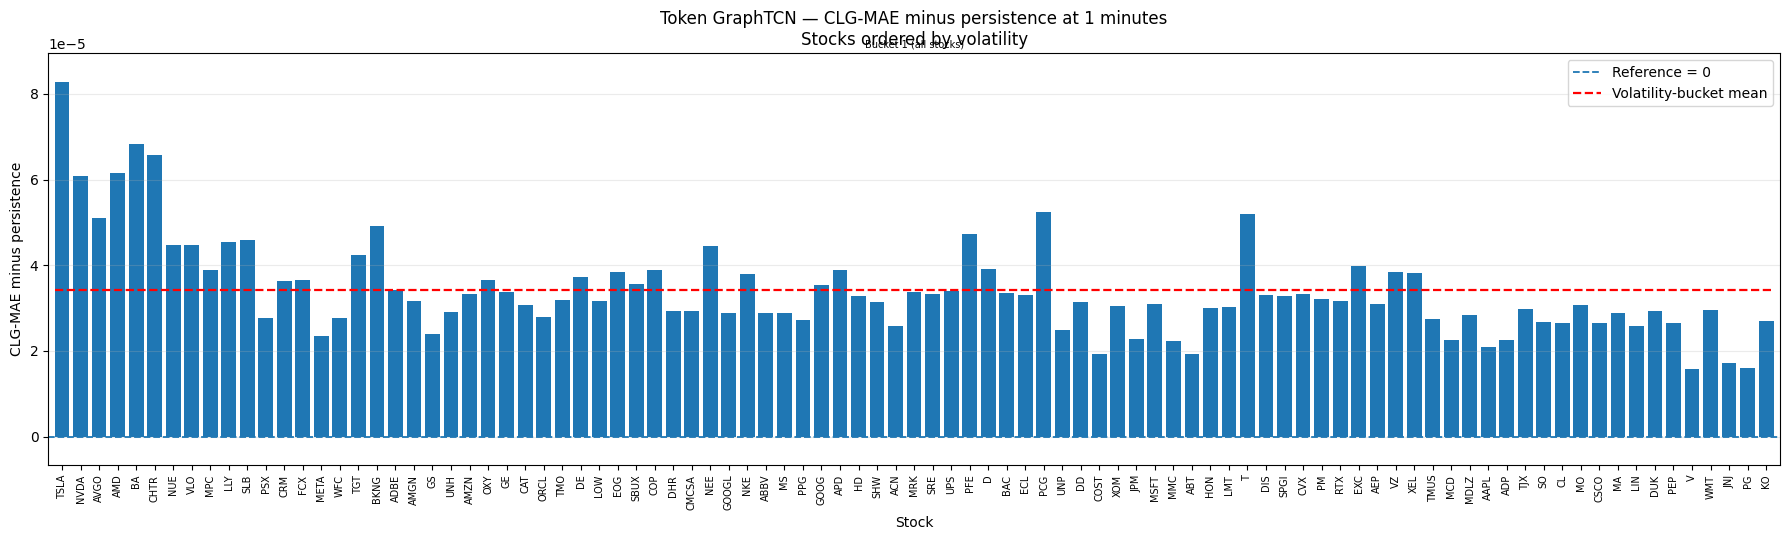

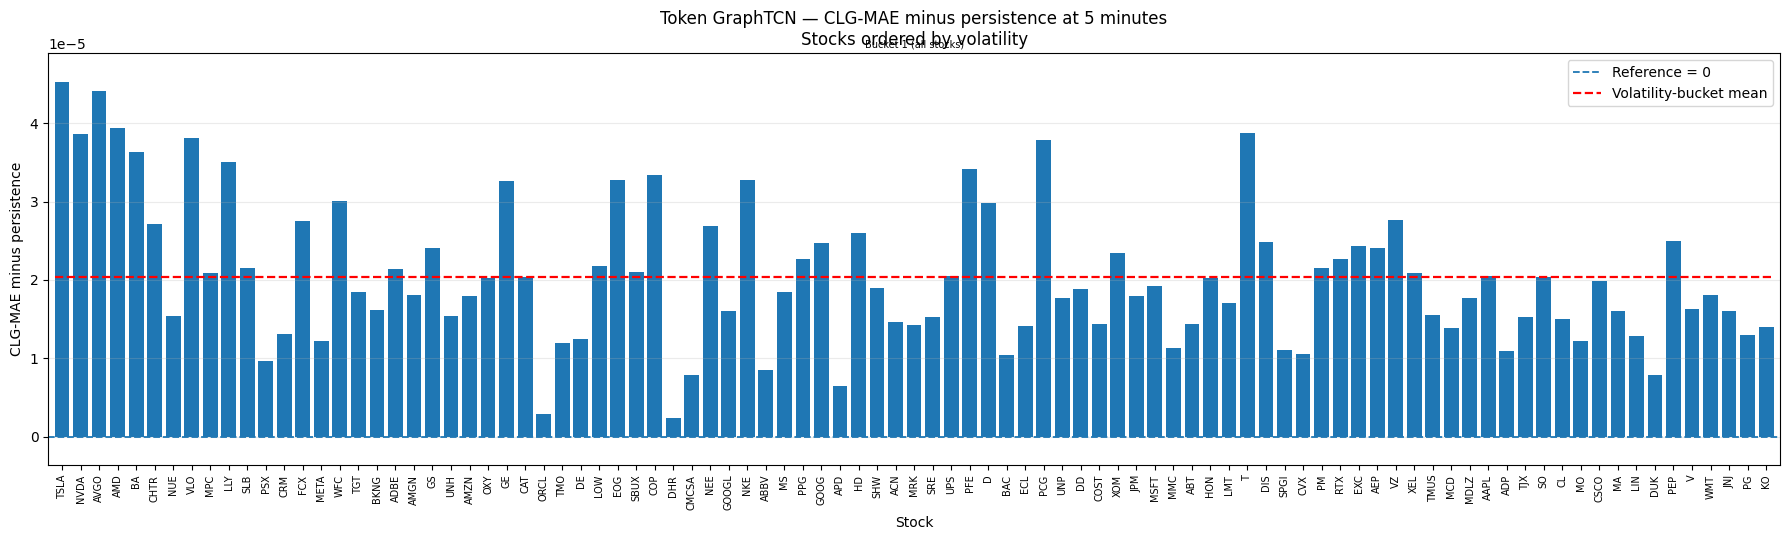

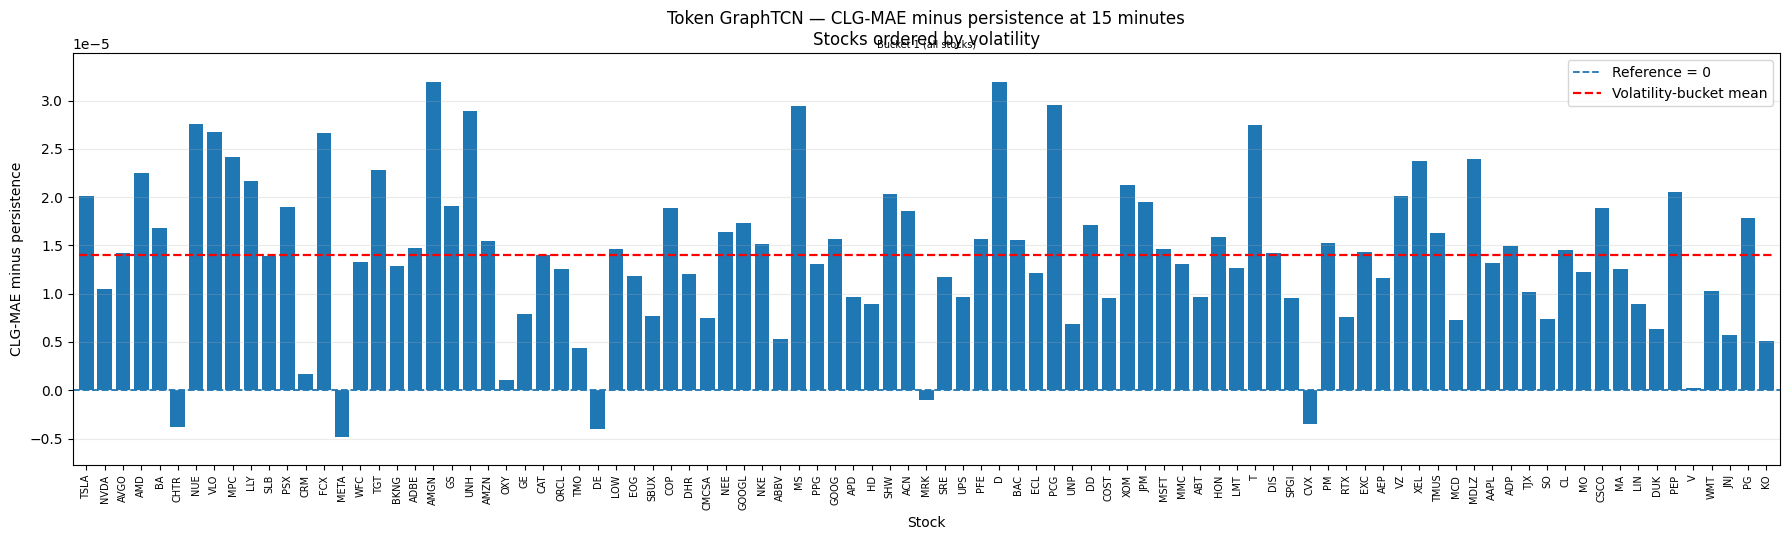

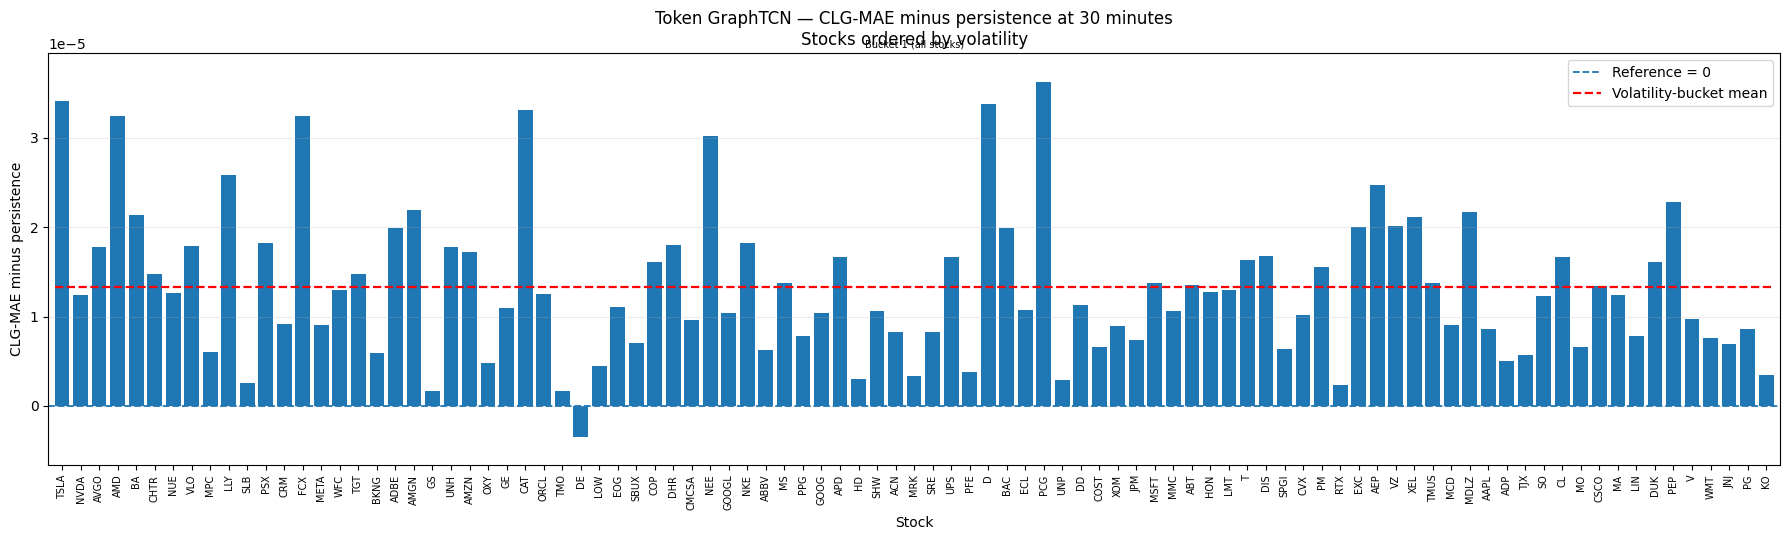

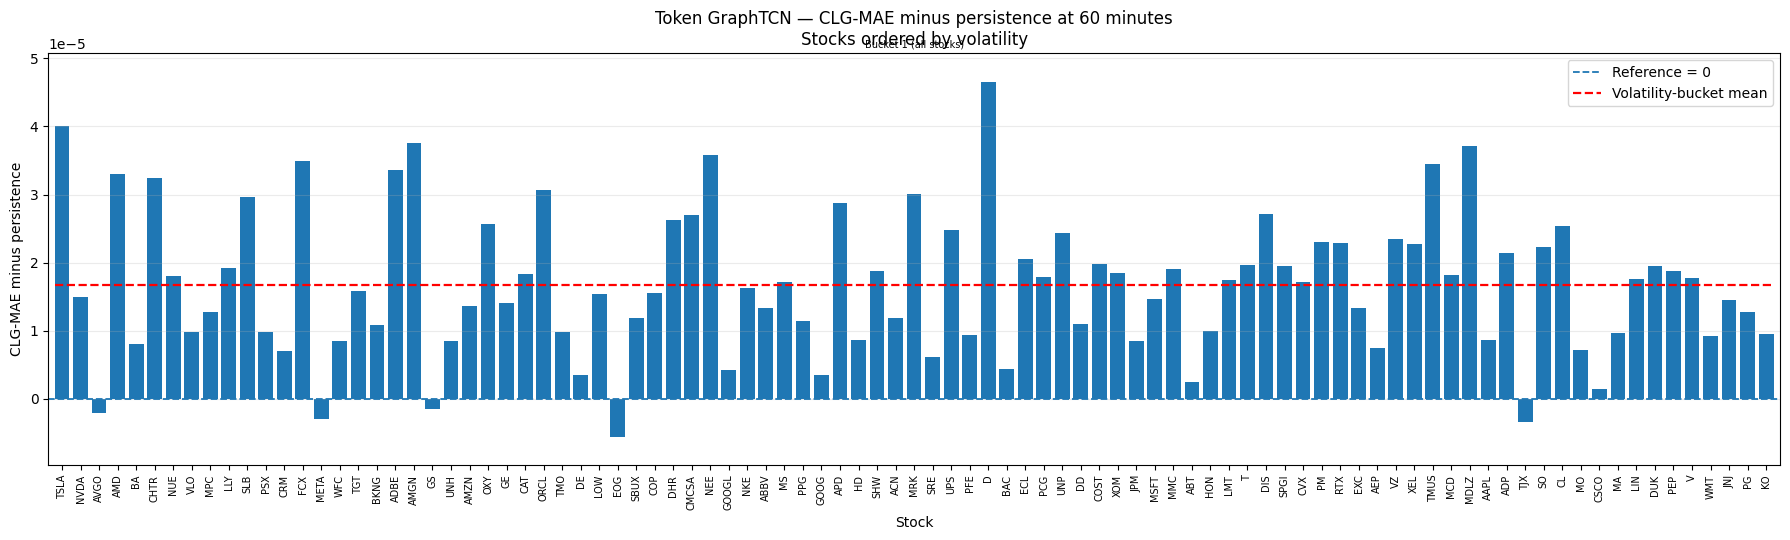

In [5]:
# Inputs:
# - model_name and metric_name are local to this cell.
# - horizons=None plots every available horizon as a separate figure.
# - order_by="sector" groups stocks by sector and orders within sector by RV.
# - num_volatility_buckets controls the bucket metadata returned with the table.
# - y_axis_mode="adaptive" uses a separate readable y-range for each horizon.
# - show_group_means=True draws one red dashed arithmetic-mean segment per sector.

sector_bar_table, sector_bar_figures = plot_stock_metric_by_horizon(
    analysis,
    model_name="Token GraphTCN",
    metric_name="mae_difference_vs_persistence",
    horizons=None,
    order_by="volatility",
    num_volatility_buckets=1,
    figsize_per_horizon=(18, 5.5),
    y_axis_mode="adaptive",
    y_padding_fraction=0.08,
    show_group_means=True,
)

### ECDF across stocks

For relative MAE, the ECDF height at one is the fraction of stocks for which a model beats persistence. This is an alternative distributional summary to the stock bar charts rather than a separate performance definition.


In [ ]:
# Inputs:
# - model_names controls the compared curves.
# - metric_name and horizon apply only to this ECDF.

ecdf_table, ecdf_figure = plot_stock_metric_ecdf(
    analysis,
    model_names=[
        "ARIMA",
        "VAR",
        "GARCH",
        "ModernTCN",
        "Kronos",
        "GraphTCN",
    ],
    metric_name="relative_mae_vs_persistence",
    horizon=60,
)


### Stocks with the strongest and weakest performance

The compact table reports only the selected top and bottom stocks. `volatility_bucket` is an equal-frequency grouping based on median test-period realised volatility: bucket 1 is the lowest-volatility group and bucket $K$ the highest, where $K$ is selected in the function call.

The output columns are:

- `value`: the selected stock-level model metric;
- `persistence_clg_mae`: persistence cumulative-log-change MAE, which also measures realised-movement headroom;
- `adf_pvalue`: the stock's ADF p-value on daily log closing prices;
- `test_median_realised_volatility`: the volatility statistic used for bucket assignment.


In [37]:
# Inputs:
# - model_name, metric_name, and horizon define the ranking.
# - top_k gives the number of best and worst stocks shown.
# - num_volatility_buckets controls the displayed equal-frequency bucket.

top_bottom_stocks = make_top_bottom_stock_table(
    analysis,
    model_name="GraphTCN",
    metric_name="mae_difference_vs_persistence",
    horizon=60,
    top_k=10,
    num_volatility_buckets=3,
)
display(top_bottom_stocks)


,group,rank_within_group,ticker,sector,volatility_bucket,volatility_bucket_label,num_volatility_buckets,test_median_realised_volatility,adf_statistic,adf_pvalue,value,persistence_clg_mae
0,Top,1,TSLA,Consumer Cyclical,3,Bucket 3 (highest),3,0.025894,-0.557731,0.880250,-0.000029,0.006125
1,Top,2,BA,Industrials,3,Bucket 3 (highest),3,0.017020,-0.422335,0.906302,-0.000024,0.004359
2,Top,3,WFC,Financial Services,3,Bucket 3 (highest),3,0.012956,-2.239109,0.192358,-0.000016,0.002883
3,Top,4,JPM,Financial Services,2,Bucket 2,3,0.009876,-2.123485,0.235177,-0.000014,0.002290
4,Top,5,BKNG,Consumer Cyclical,3,Bucket 3 (highest),3,0.012691,-1.852550,0.354702,-0.000010,0.002482
5,Top,6,HD,Consumer Cyclical,2,Bucket 2,3,0.010658,-1.324302,0.617982,-0.000010,0.002303
6,Top,7,BAC,Financial Services,2,Bucket 2,3,0.010107,-2.031340,0.273003,-0.000009,0.002330
7,Top,8,GS,Financial Services,3,Bucket 3 (highest),3,0.012178,-1.779735,0.390568,-0.000009,0.002711
8,Top,9,CRM,Technology,3,Bucket 3 (highest),3,0.013331,-1.718372,0.421673,-0.000007,0.003076
9,Top,10,GOOG,Communication Services,2,Bucket 2,3,0.010752,-0.754827,0.832033,-0.000007,0.002713


## 3. Mean performance by test-period stock volatility

Stocks are assigned to $K$ equal-frequency groups using

$$
\widetilde{RV}_{n}=\operatorname{median}_{d}\left(RV_{d,n}\right).
$$

Bucket 1 contains the lowest-volatility stocks and bucket $K$ the highest. `num_volatility_buckets` can be changed independently in this cell; no k-means or learned clustering is used.

For each selected model, horizon, and bucket, the plotted quantity is the arithmetic mean of the stock-level metric:

$$
\overline{M}_{m,h,k}=\frac{1}{N_k}\sum_{n\in k}M_{m,h,n}.
$$

The plot contains simple lines with markers only: no bars, interquartile ranges, or error bars. One line is drawn for each selected `(model, horizon)` pair.

When `metric_name="relative_mae_vs_persistence"`, the returned table also includes `fraction_of_stocks_beating_persistence`, defined as

$$
\frac{1}{N_k}\sum_{n\in k}\mathbf{1}\!\left[\operatorname{RelMAE}_{m,h,n}<1\right].
$$

The table also reports the number of valid stocks and the minimum, mean, and maximum realised volatility in each bucket.


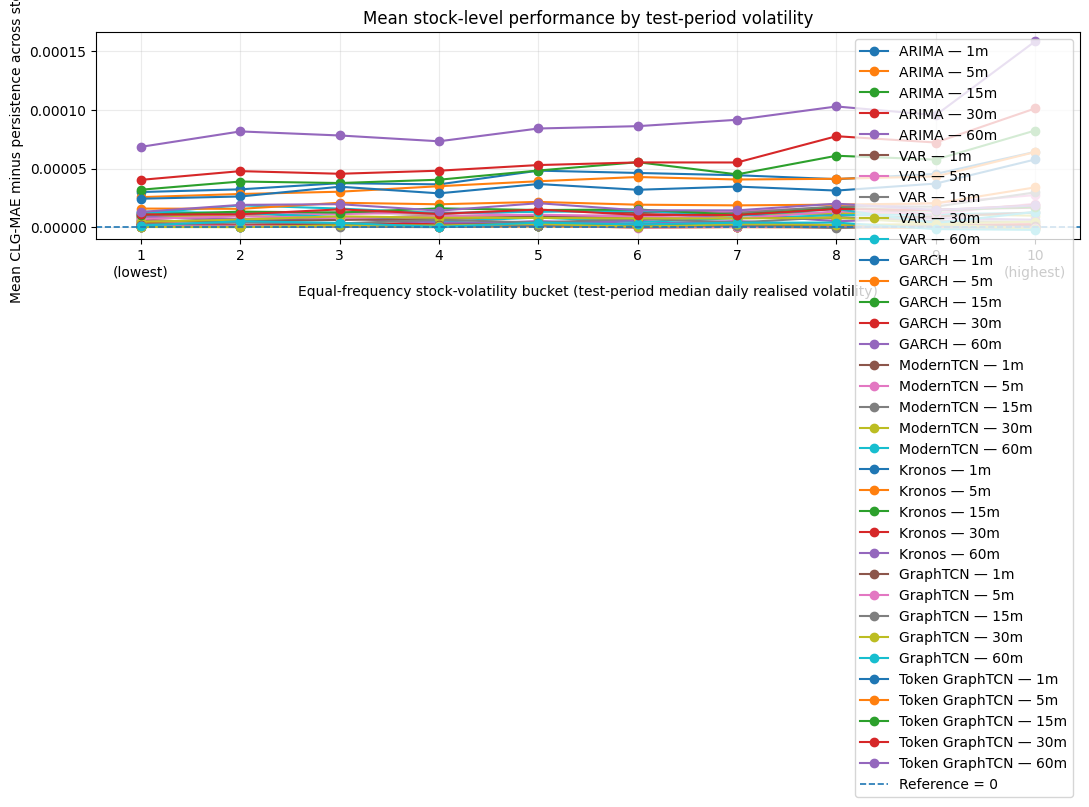

In [13]:
# Compare model performance across stock-volatility buckets.
#
# model_names=None:
#     Include every loaded model except persistence.
#
# metric_name="mae_difference_vs_persistence":
#     Report each model's Log MAE minus persistence Log MAE.
#     Negative values indicate an improvement over persistence.
#
# num_volatility_buckets=10:
#     Bucket 1 contains the lowest-volatility stocks.
#     Bucket 10 contains the highest-volatility stocks.
#
# return_extreme_table=True:
#     Also return a compact table containing only buckets 1 and 10.

(
    volatility_bucket_summary,
    volatility_extreme_table,
    volatility_bucket_figure,
) = plot_metric_by_stock_volatility(
    analysis,
    model_names=None,
    metric_name="mae_difference_vs_persistence",
    horizons=[1, 5, 15, 30, 60],
    num_volatility_buckets=10,
    figsize=(11, 6),
    return_extreme_table=True,
)

display(
    volatility_extreme_table.style
    .format("{:+.3f}")
    .set_caption(
        "Log MAE difference from persistence by stock volatility (bps)"
    )
)


## 4. Performance by actual prediction time

Buckets are assigned using the **target bar-close timestamp** for each `(window, horizon)` prediction:

$$
b(t_{\mathrm{target}})=
\begin{cases}
\text{Morning}, & t_{\mathrm{target}}<12{:}00,\\
\text{Midday}, & 12{:}00\le t_{\mathrm{target}}<15{:}30,\\
\text{Late session}, & t_{\mathrm{target}}\ge15{:}30.
\end{cases}
$$

Because all horizons share the same forecast origins, late-session observations exist only where the horizon reaches those target times.  Empty combinations are shown as missing rather than zero.

For `mae_difference_vs_persistence`, the plotted quantity is recomputed inside each target-time bucket:

$$
\Delta \operatorname{MAE}^{\mathrm{CLG}}_{m,b,h}
=
\operatorname{MAE}^{\mathrm{CLG}}_{m,b,h}
-
\operatorname{MAE}^{\mathrm{CLG}}_{\mathrm{Persistence},b,h}.
$$

Negative values favour the selected model, and zero is persistence parity.


Morning                           \
                                   value num_windows num_sessions   
horizon model_display_name                                          
1       GraphTCN            1.455806e-06         620           62   
5       GraphTCN            5.634127e-07         620           62   
15      GraphTCN           -1.243760e-06         558           62   
30      GraphTCN            2.240295e-07         496           62   
60      GraphTCN            2.004280e-06         372           62   

                                  Midday                           \
                                   value num_windows num_sessions   
horizon model_display_name                                          
1       GraphTCN            1.999623e-06         558           62   
5       GraphTCN            6.654864e-07         558           62   
15      GraphTCN            1.840400e-06         620           62   
30      GraphTCN            2.088706e-06         682           62   
60      GraphTCN            2.147622e-06         806           62   

                           Late session               
                            num_windows num_sessions  
horizon model_display_name                            
1       GraphTCN                      0            0  
5       GraphTCN                      0            0  
15      GraphTCN                      0            0  
30      GraphTCN                      0            0  
60      GraphTCN                      0            0

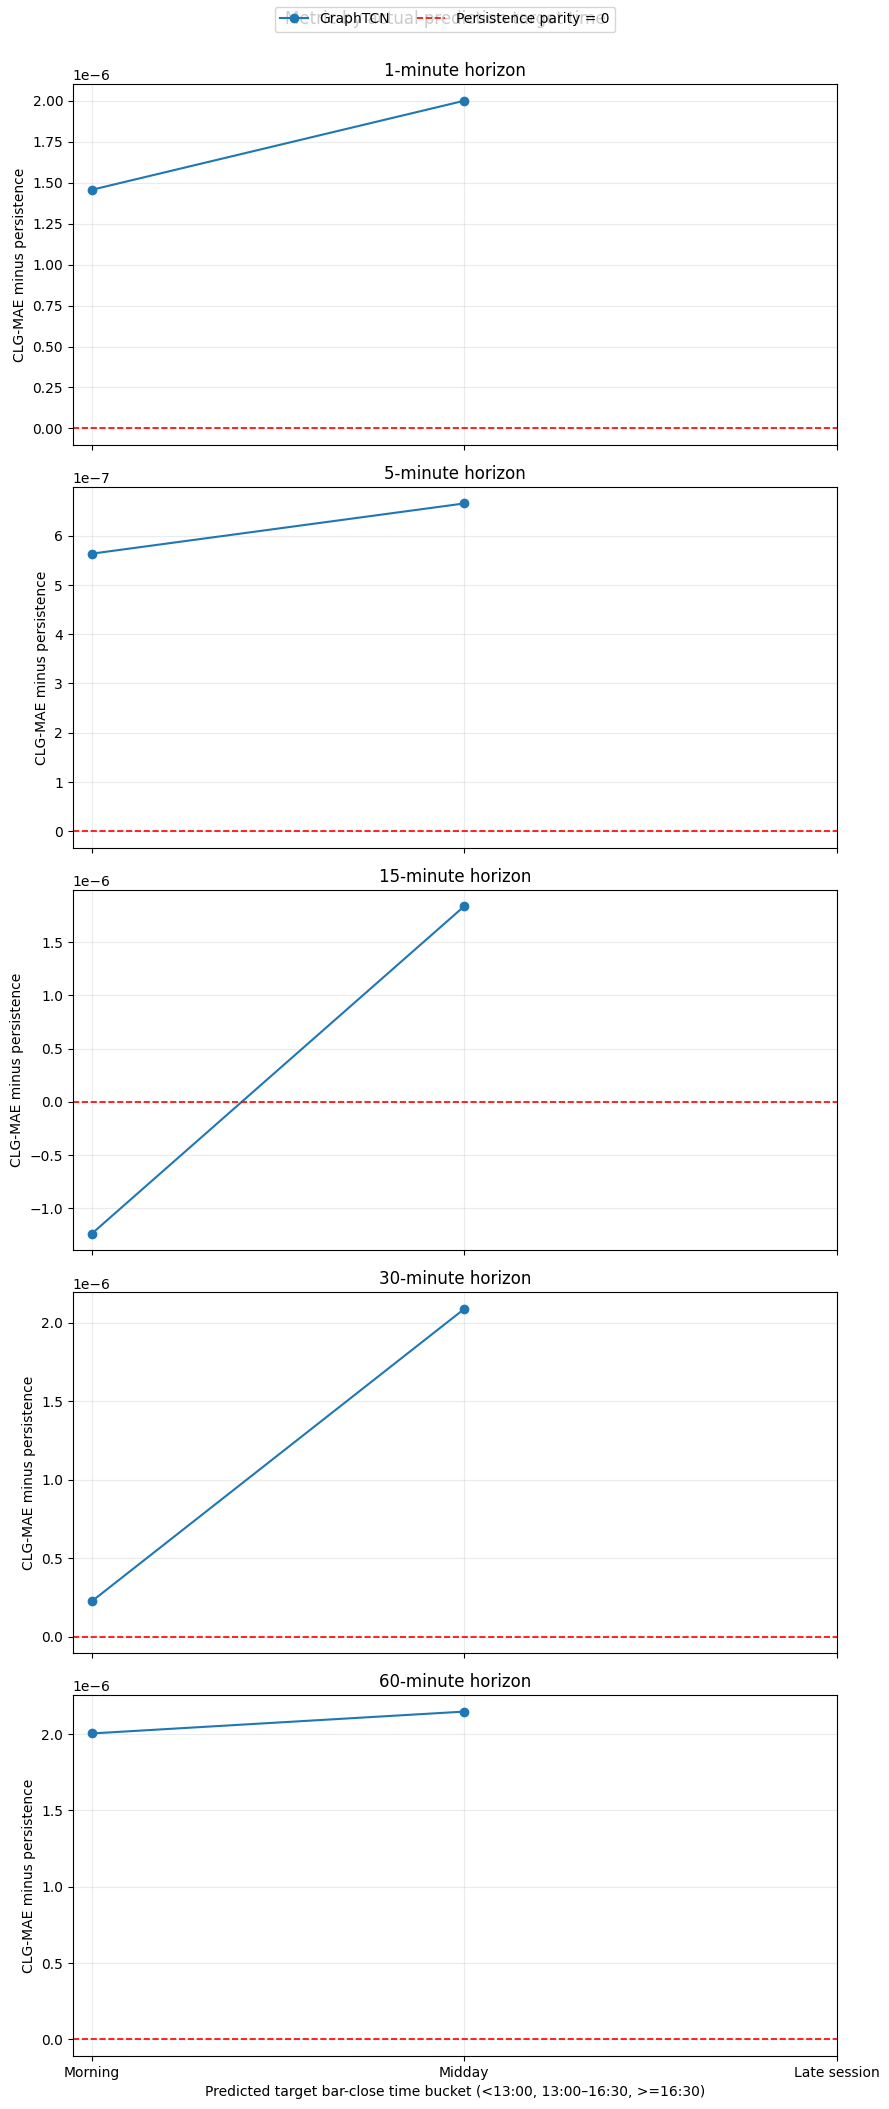

In [16]:
# Inputs:
# - model_names selects all models shown in each horizon panel.
# - metric_name may be any group-level metric, including IC, Rank IC,
#   or "mae_difference_vs_persistence".
# - horizons controls the displayed forecast horizons.
# - cutoffs refer to actual predicted target times, not forecast origins.

time_of_day_results, time_of_day_figure = plot_time_of_day_metric(
    analysis,
    model_names=[
        #"Persistence",
        #"ARIMA",
        #"VAR",
        #"GARCH",
        #"ModernTCN",
        #"Kronos",
        "GraphTCN",
    ],
    metric_name="mae_difference_vs_persistence",
    horizons=[1, 5, 15, 30, 60],
    morning_cutoff="13:00",
    late_session_cutoff="16:30",
)
display(make_time_of_day_metric_table(time_of_day_results))


## 5. Daily GraphTCN error difference

For model $m$, benchmark $b$, session $d$, and horizon $h$,

$$
\Delta E_{d,m,h}=E_{d,m,h}-E_{d,b,h}.
$$

For an error metric, negative values mean that the selected model beats the benchmark on that day.  The cumulative option shows whether gains or losses accrue gradually or are driven by a few sessions.

In [ ]:
# Inputs:
# - model_name and benchmark_name define the paired comparison.
# - horizon and metric_name apply only to this daily series.
# - cumulative=False shows day-by-day differences.

daily_error_table, daily_error_figure = plot_daily_error_difference(
    analysis,
    model_name="GraphTCN",
    benchmark_name="Persistence",
    horizon=60,
    metric_name="cumulative_log_change_mae",
    cumulative=False,
)


## 6. Daily model metric versus market volatility

For model $m$, session $d$, horizon $h$, and a selected metric $M$, the scatter shows

$$
\left(RV_d^{\mathrm{market}},\;M_{d,m,h}\right).
$$

The function plots the model's **own daily metric**. It does not subtract a second model. Metrics that are already defined relative to persistence remain relative by their own definitions:

- `mae_difference_vs_persistence`: daily cumulative-log-change MAE minus persistence cumulative-log-change MAE; zero is parity.
- `relative_mae_vs_persistence`: the existing daily MAE ratio; one is parity.
- `persistence_win_rate`: the existing daily pointwise win rate; $0.5$ is parity.

Other metrics, including Pearson correlation, IC, and Rank IC, are plotted directly for the selected model rather than as differences against persistence. Pearson and Spearman in the summary describe the association between the selected daily metric and daily realised volatility.


,model,horizon,metric,metric_display_name,pearson,spearman,sessions,is_persistence_relative
0,GraphTCN,1,mae_difference_vs_persistence,CLG-MAE minus persistence,-0.252535,-0.221677,62,True


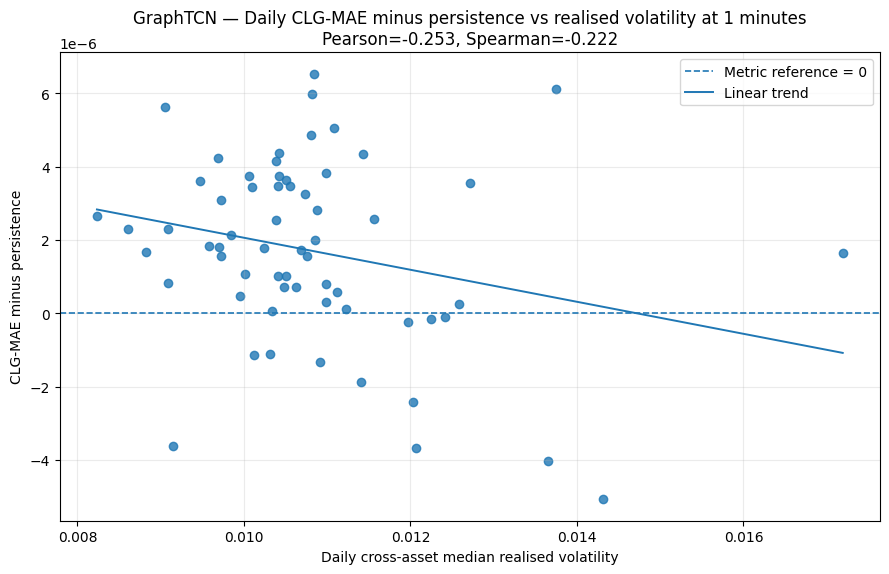

In [23]:
# Inputs:
# - model_name selects the model whose own daily metric is plotted.
# - metric_name may be any evaluator metric, or
#   "mae_difference_vs_persistence" for daily CLG-MAE minus persistence.
# - horizon selects one forecast horizon.
# - annotate_extremes labels the lowest and highest daily metric values.
# - show_reference_line draws the metric's natural reference, when defined.

daily_volatility_table, daily_volatility_figure = (
    plot_daily_metric_vs_volatility(
        analysis,
        model_name="GraphTCN",
        horizon=1,
        metric_name="mae_difference_vs_persistence",
        annotate_extremes=0,
        show_reference_line=True,
    )
)
display(summarise_daily_metric_vs_volatility(daily_volatility_table))


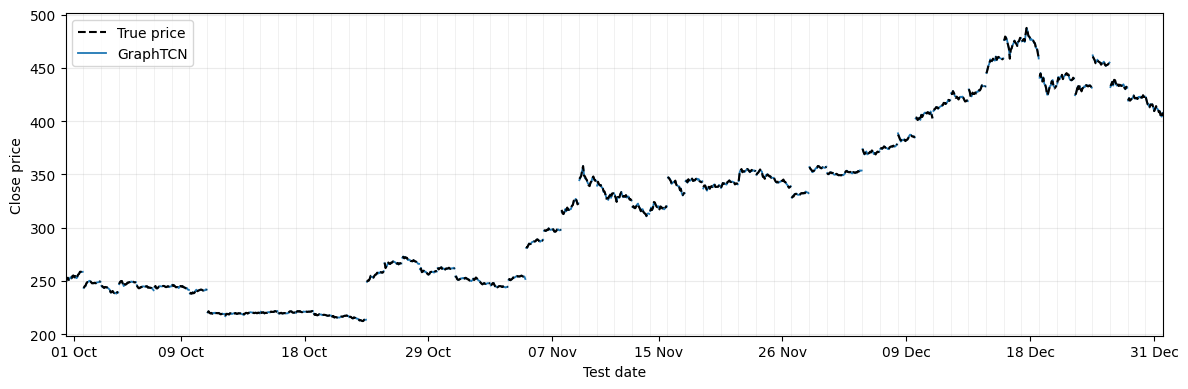

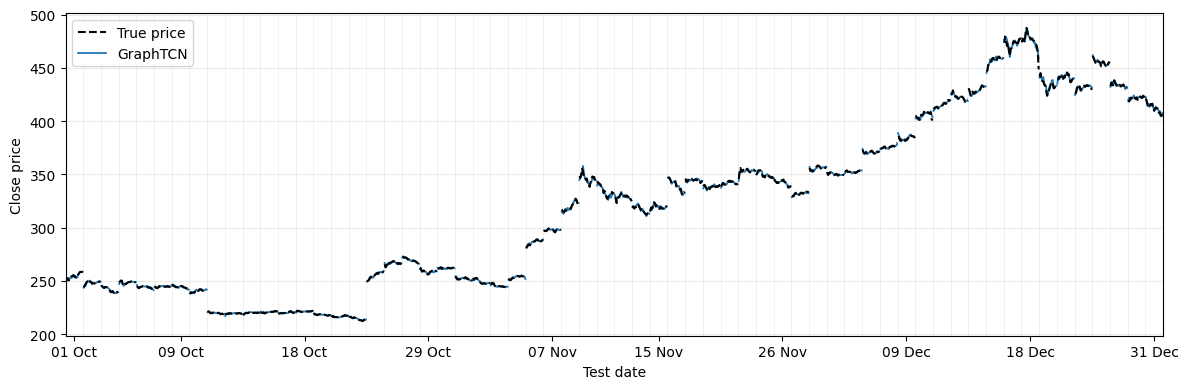

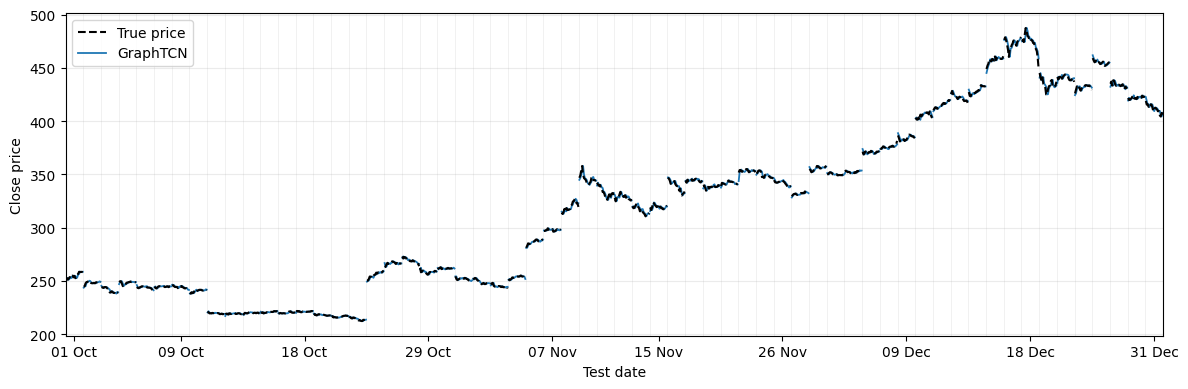

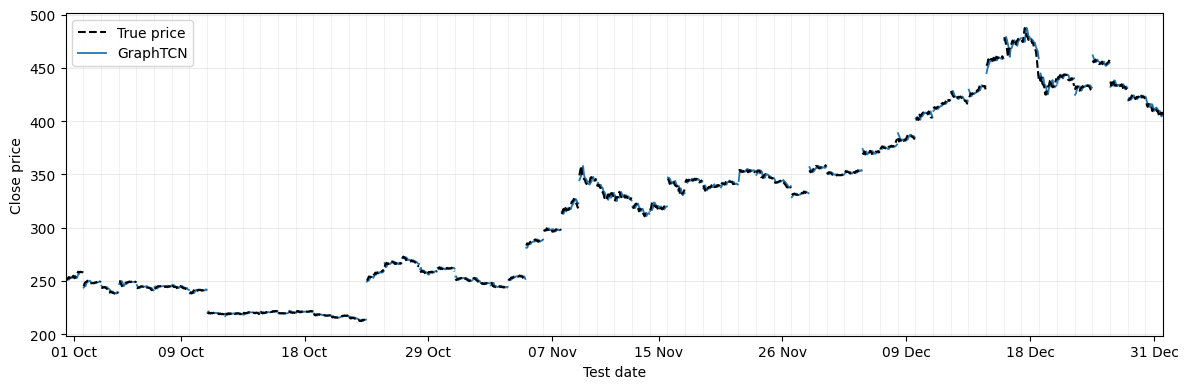

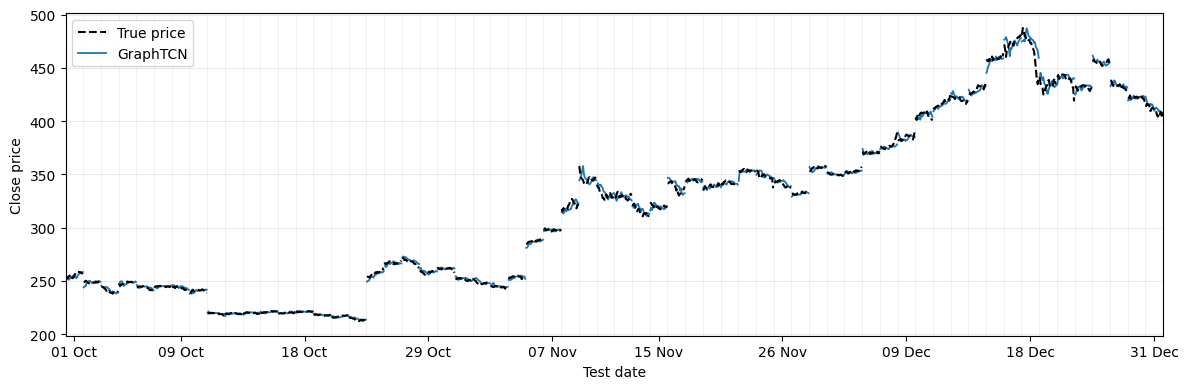

In [10]:
# Plot raw Close-price forecasts for one stock.
#
# Inputs:
# - PLOT_MODELS: models already loaded into the `analysis` object.
# - PLOT_ASSET: stock ticker to plot.
# - PLOT_DAYS:
#       None              -> complete test set
#       slice(0, 5)       -> first five test days
#       slice(10, 20)     -> test days 11 to 20
#       slice(-5, None)   -> final five test days
# - PLOT_HORIZONS: one separate figure is produced per horizon.
# - SHOW_TITLES: False produces clean figures for LaTeX.

PLOT_MODELS = [
    "GraphTCN",
]

PLOT_ASSET = "TSLA"

# Use the complete test set.
PLOT_DAYS = None

PLOT_HORIZONS = [
    1,
    5,
    15,
    30,
    60,
]

SHOW_TITLES = False
SAVE_PLOTS = False

FORECAST_PLOT_DIR = (
    ANALYSIS_OUTPUT_DIR
    / "forecast_examples"
    / PLOT_ASSET
)

forecast_plot_data, forecast_figures = (
    plot_price_forecasts_across_days(
        analysis,
        model_names=PLOT_MODELS,
        asset=PLOT_ASSET,
        days=PLOT_DAYS,
        horizons=PLOT_HORIZONS,
        display_names={
            "Persistence": "Persistence",
            "GraphTCN": "GraphTCN",
        },
        title=SHOW_TITLES,
        figsize=(12, 4),
    )
)

if SAVE_PLOTS:
    FORECAST_PLOT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    for horizon, figure in forecast_figures.items():
        output_path = (
            FORECAST_PLOT_DIR
            / f"{PLOT_ASSET.lower()}_{horizon}min_forecast.pdf"
        )

        figure.savefig(
            output_path,
            bbox_inches="tight",
        )

        print(f"Saved: {output_path}")



## Export reusable analysis tables

This writes aligned manifests, stock characteristics, ADF diagnostics, daily realised volatility, and the complete per-stock metric table.  Existing model artefacts are never modified.

In [ ]:
# Input:
# - ANALYSIS_OUTPUT_DIR is the destination for reusable CSV/JSON tables.

exported_paths = analysis.export_tables(
    ANALYSIS_OUTPUT_DIR,
    include_per_stock_metrics=True,
)
display(
    pd.DataFrame(
        {
            "table": list(exported_paths),
            "path": [str(path) for path in exported_paths.values()],
        }
    )
)
